# Medallion Architecture Walkthrough  
## Cleaning the Messy v2 Dataset Step-by-Step

This notebook teaches how to clean a messy retail sales dataset using a **Medallion Architecture** approach:

- **Bronze** → landed raw data
- **Silver** → cleaned, validated, business-rule compliant data
- **Gold** → analytics-ready data

The source file used in this lab is:

```text
dataset_messy.csv
```

---

## What this notebook emphasizes

For every major transformation, we explain:

- **Why** the rule matters
- **Business value**
- **How** the SQL works
- **What** the plot means

---

## Core Business Rules Applied

1. exact duplicates are dropped  
2. invalid or missing `sale_id` → cancelled  
3. missing `sale_type` → reject  
4. missing `sales_channel` → impute `UNKNOWN`  
5. missing `product_name` → reject  
6. invalid or missing `customer_email` → reject  
7. invalid `customer_gender` → impute `UNKNOWN` *(if present in future datasets)*  
8. `quantity` must be integer > 0  
9. `unit_price` must be > 0  
10. invalid / missing `discount` → impute `0.00`  
11. invalid / missing `store_location` → reject  
12. invalid / missing `sale_date` → reject  

This notebook is designed for teaching and discussion, not just execution.


## Cell 01 — Import libraries and connect to DuckDB

### Why
We need:
- SQL execution with DuckDB
- table inspection with pandas
- plotting with matplotlib

### Business value
A lightweight warehouse environment lets students focus on **data quality logic** instead of infrastructure.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("medallion_v2.duckdb")
print("Connected to DuckDB.")

Connected to DuckDB.


## Cell 02 — Define the source file

### Why
Keeping the CSV path in one variable makes the notebook easier to rerun and modify.

### Business value
In real pipelines, the source file changes by batch or date, so parameterizing the file name is a standard practice.


In [2]:
csv_file = "dataset_messy.csv"
print("Using source file:", csv_file)

Using source file: dataset_messy.csv


## Cell 03 — Preview the raw file with pandas

### Why
Before we apply rules, we need to see the mess.

### Business value
Data profiling starts with inspection. Students should recognize:
- missing values
- malformed values
- suspicious records


In [3]:
df_preview = pd.read_csv(csv_file, dtype=str)
df_preview.head(10)

,sale_id,sale_type,sales_channel,product_name,product_category,product_brand,customer_name,customer_email,customer_country,customer_city,...,unit_price,cost_price,discount,store_location,store_region,store_manager,sale_date,order_timestamp,delivery_date,order_status
0,1,IN-STORE,STORE,IPAD,TABLET,Apple,Claire Moreau,claire.moreau41@outlook.com,FRANCE,Paris,...,1014.0,778.06,0.0,CHINA,EAST,Li Chen,07/07/2016,2016-07-07 10:44:47,2016-07-09,COMPLETED
1,2,ON-LINE,WEB,COMPUTER,COMPUTERS,HP,Hans Martin,hans.martin76@yahoo.com,CANADA,Vancouver,...,965.0,727.44,0.0,ENGLAND,NORTH,Grace Turner,04/19/2017,2017-04-19 17:35:36,2017-04-24,COMPLETED
2,3,IN-STORE,STORE,IPAD,TABLET,Apple,George Taylor,george.taylor81@icloud.com,CHINA,Shenzhen,...,402.0,275.57,0.0,USA,WEST,Jay Smith,2015-06-03,2015-06-03 19:58:41,2015-06-10,COMPLETED
3,4,IN-STORE,STORE,COMPUTER,COMPUTERS,HP,William Miller,william.miller2@icloud.com,INDIA,Mumbai,...,949.0,693.37,0.0,CANADA,WEST,Noah Bennett,2015-07-11,2015-07-11 20:51:17,2015-07-15,COMPLETED
4,5,ON-LINE,WEB,MACBOOK,COMPUTERS,Apple,Scarlett Sanchez,scarlett.sanchez46@gmail.com,CHINA,Shenzhen,...,2082.0,1627.93,104.1,CANADA,CENTRAL,Noah Bennett,08/17/2015,2015-08-17 15:46:59,2015-08-23,COMPLETED
5,6,IN-STORE,STORE,COMPUTER,COMPUTERS,Lenovo,Oliver Wang,oliver.wang81@outlook.com,CANADA,Toronto,...,822.0,645.34,0.0,CHINA,SOUTH,Li Chen,12/12/2015,2015-12-12 13:45:17,2015-12-19,COMPLETED
6,7,ON-LINE,WEB,HELMET,ACCESSORY,Specialized,Matthew Phillips,matthew.phillips68@proton.me,GERMANY,Berlin,...,132.0,103.73,66.0,USA,WEST,Jay Smith,2016-09-28,2016-09-28 16:40:52,2016-09-29,COMPLETED
7,8,ON-LINE,WEB,HELMET,ACCESSORY,Bell,Alexander Anderson,alexander.anderson12@icloud.com,GERMANY,Berlin,...,94.0,68.18,0.0,USA,EAST,Jay Smith,2017-09-22,2017-09-22 16:14:06,2017-09-26,COMPLETED
8,9,IN-STORE,STORE,HEADPHONES,AUDIO,Bose,Harper Phillips,harper.phillips65@outlook.com,CANADA,Vancouver,...,193.0,137.08,0.0,CHINA,SOUTH,Li Chen,04/01/2017,2017-04-01 18:43:09,2017-04-04,COMPLETED
9,10,IN-STORE,STORE,IPAD,TABLET,Apple,Logan Phillips,logan.phillips84@outlook.com,GERMANY,Munich,...,1041.0,646.01,0.0,CHINA,SOUTH,Li Chen,04/03/2017,2017-04-03 21:18:41,2017-04-09,COMPLETED


In [4]:
df_preview.shape

(18490, 23)

## Cell 04 — Create schemas and load Raw/Bronze

### Why
Schemas make the medallion layers visible:
- `raw`
- `bronze`
- `silver`
- `gold`

### Business value
Schema separation is a design habit that improves maintainability and auditability.


In [5]:
con.execute("CREATE SCHEMA IF NOT EXISTS raw;")
con.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
con.execute("CREATE SCHEMA IF NOT EXISTS silver;")
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")

con.execute(f"""
CREATE OR REPLACE TABLE raw.sales_file AS
SELECT
    ROW_NUMBER() OVER () AS raw_row_num,
    *
FROM read_csv_auto('{csv_file}', header=true, all_varchar=true);
""")

con.execute("""
CREATE OR REPLACE TABLE bronze.sales_raw AS
SELECT *
FROM read_csv_auto('dataset_messy.csv');
""")

con.execute("""
SELECT COUNT(*) AS bronze_rows 
FROM bronze.sales_raw
""").df()

,bronze_rows
0,18490


## Cell 05 — Inspect Bronze structure

### Why
We need to know the landed columns and types before cleaning.

### Business value
This is the warehouse equivalent of understanding the source system contract.


In [6]:
con.execute("""
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'bronze'
  AND table_name = 'sales_raw'
ORDER BY ordinal_position;
""").df()

,column_name,data_type
0,sale_id,VARCHAR
1,sale_type,VARCHAR
2,sales_channel,VARCHAR
3,product_name,VARCHAR
4,product_category,VARCHAR
5,product_brand,VARCHAR
6,customer_name,VARCHAR
7,customer_email,VARCHAR
8,customer_country,VARCHAR
9,customer_city,VARCHAR


## Cell 06 — Bronze quality profile

### Why
We establish a baseline before transforming anything.

### Business value
This gives stakeholders a quick summary of how messy the incoming batch is.


In [7]:
con.execute("""
WITH dups AS (
    SELECT
        sale_id,
        sale_type,
        sales_channel,
        product_name,
        customer_email,
        customer_country,
        quantity,
        unit_price,
        cost_price,
        discount,
        store_location,
        sale_date,
        COUNT(*) AS cnt
    FROM bronze.sales_raw
    GROUP BY
        sale_id,
        sale_type,
        sales_channel,
        product_name,
        customer_email,
        customer_country,
        quantity,
        unit_price,
        cost_price,
        discount,
        store_location,
        sale_date
    HAVING COUNT(*) > 1
),

metrics AS (
    SELECT
        COUNT(*) AS total_rows,

        SUM(CASE 
            WHEN NULLIF(TRIM(sale_id), '') IS NULL THEN 1 
            ELSE 0 
        END) AS missing_sale_id_rows,

        SUM(CASE 
            WHEN NULLIF(TRIM(product_name), '') IS NULL THEN 1 
            ELSE 0 
        END) AS missing_product_rows,

        SUM(CASE 
            WHEN NULLIF(TRIM(customer_email), '') IS NULL THEN 1 
            ELSE 0 
        END) AS missing_customer_email_rows,

        SUM(CASE 
            WHEN NULLIF(TRIM(store_location), '') IS NULL THEN 1 
            ELSE 0 
        END) AS missing_store_location_rows,

        SUM(CASE 
            WHEN NULLIF(TRIM(sale_date), '') IS NULL THEN 1 
            ELSE 0 
        END) AS missing_sale_date_rows,

        COALESCE(
            (SELECT SUM(cnt - 1) FROM dups),
            0
        ) AS extra_duplicate_rows

    FROM bronze.sales_raw
)

SELECT 'total_rows' AS metric, total_rows AS value FROM metrics
UNION ALL
SELECT 'missing_sale_id_rows', missing_sale_id_rows FROM metrics
UNION ALL
SELECT 'missing_product_rows', missing_product_rows FROM metrics
UNION ALL
SELECT 'missing_customer_email_rows', missing_customer_email_rows FROM metrics
UNION ALL
SELECT 'missing_store_location_rows', missing_store_location_rows FROM metrics
UNION ALL
SELECT 'missing_sale_date_rows', missing_sale_date_rows FROM metrics
UNION ALL
SELECT 'extra_duplicate_rows', extra_duplicate_rows FROM metrics;
""").df()

,metric,value
0,total_rows,18490.0
1,missing_sale_id_rows,630.0
2,missing_product_rows,110.0
3,missing_customer_email_rows,110.0
4,missing_store_location_rows,80.0
5,missing_sale_date_rows,80.0
6,extra_duplicate_rows,500.0


## Cell 07 — Plot Bronze issue counts

### Why
A visual summary makes data quality discussions more concrete.

### How to read the plot
Higher bars indicate where the dataset is dirtiest.

### Business value
The plot helps answer: *Where should the cleaning effort focus first?*


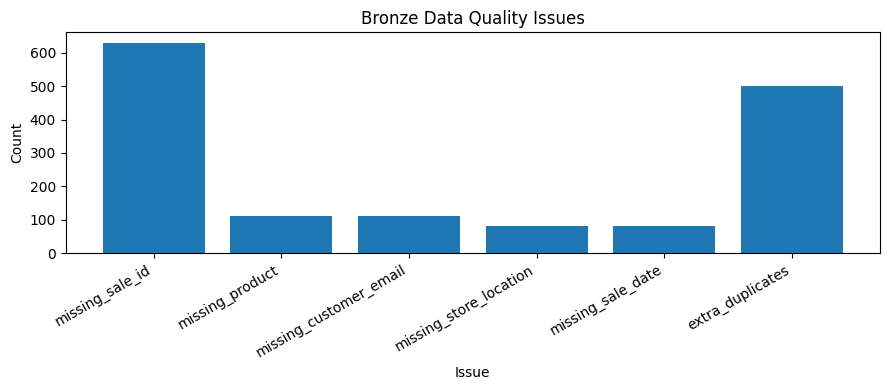

In [8]:
df_bronze_issues = con.execute("""
WITH dups AS (
    SELECT
        sale_id, sale_type, sales_channel, product_name, customer_email,
        customer_country, quantity, unit_price, cost_price, discount, store_location, sale_date,
        COUNT(*) AS cnt
    FROM bronze.sales_raw
    GROUP BY
        sale_id, sale_type, sales_channel, product_name, customer_email,
        customer_country, quantity, unit_price, cost_price, discount, store_location, sale_date
    HAVING COUNT(*) > 1
)
SELECT 'missing_sale_id' AS issue, SUM(CASE WHEN NULLIF(TRIM(sale_id), '') IS NULL THEN 1 ELSE 0 END) AS issue_count FROM bronze.sales_raw
UNION ALL
SELECT 'missing_product', SUM(CASE WHEN NULLIF(TRIM(product_name), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'missing_customer_email', SUM(CASE WHEN NULLIF(TRIM(customer_email), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'missing_store_location', SUM(CASE WHEN NULLIF(TRIM(store_location), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'missing_sale_date', SUM(CASE WHEN NULLIF(TRIM(sale_date), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'extra_duplicates', COALESCE((SELECT SUM(cnt - 1) FROM dups), 0);
""").df()

plt.figure(figsize=(9,4))
plt.bar(df_bronze_issues["issue"], df_bronze_issues["issue_count"])
plt.title("Bronze Data Quality Issues")
plt.xlabel("Issue")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Plot interpretation

This plot shows the main quality issues before any Silver cleaning.

A larger bar means that issue affects more rows. In real data engineering work, this helps prioritize transformations and stakeholder communication.


# Silver Layer — Step-by-Step Cleaning

Silver is where we apply business rules one by one and make every decision auditable.


## Cell 08 — Step 1: Deduplicate exact duplicate rows

### Why
Duplicate rows inflate revenue, transactions, and counts.

### Business value
Without deduplication, business dashboards become misleading.

### How
We use `SELECT DISTINCT` across all business columns.


In [9]:
con.execute("""
CREATE OR REPLACE TABLE silver.step01_dedup AS
SELECT DISTINCT
    -- =========================
    -- CORE
    -- =========================
    sale_id,
    sale_type,
    sales_channel,

    -- =========================
    -- PRODUCT
    -- =========================
    product_name,
    product_category,
    product_brand,

    -- =========================
    -- CUSTOMER
    -- =========================
    customer_name,
    customer_email,
    customer_country,
    customer_city,
    customer_gender,
    customer_segment,

    -- =========================
    -- MEASURES
    -- =========================
    quantity,
    unit_price,
    cost_price,
    discount,

    -- =========================
    -- STORE
    -- =========================
    store_location,
    store_region,
    store_manager,

    -- =========================
    -- DATE / TIME
    -- =========================
    sale_date,
    order_timestamp,
    delivery_date,
    order_status

FROM bronze.sales_raw;
""")

In [10]:
con.execute("""
SELECT COUNT(*) AS num_of_rows_silver_step01_dedup
FROM silver.step01_dedup 
""").df()

,num_of_rows_silver_step01_dedup
0,18070


In [11]:
con.execute("""
SELECT * 
FROM silver.step01_dedup 
LIMIT 5;
""").df()

,sale_id,sale_type,sales_channel,product_name,product_category,product_brand,customer_name,customer_email,customer_country,customer_city,...,unit_price,cost_price,discount,store_location,store_region,store_manager,sale_date,order_timestamp,delivery_date,order_status
0,17,ON-LINE,WEB,MACBOOK,COMPUTERS,Apple,Evelyn Lee,evelyn.lee38@yahoo.com,FRANCE,Lyon,...,2022.0,1498.66,0.0,CHINA,EAST,Li Chen,01/16/2017,2017-01-16 15:17:24,2017-01-24,COMPLETED
1,19,IN-STORE,STORE,EBIKE,MOBILITY,Trek,Lily Miller,lily.miller69@gmail.com,USA,New York,...,2123.0,1529.41,0.0,CHINA,SOUTH,Wei Zhang,12/07/2016,2016-12-07 17:18:27,2016-12-07,COMPLETED
2,37,IN-STORE,STORE,HELMET,ACCESSORY,Specialized,Amelia Walker,amelia.walker26@proton.me,GERMANY,Berlin,...,83.0,63.77,0.0,USA,EAST,Linda Parker,06/17/2015,2015-06-17 08:42:28,2015-06-19,COMPLETED
3,42,ON-LINE,MOBILE_APP,WATCH,WEARABLE,Apple,Amir Perez,amir.perez69@outlook.com,ENGLAND,Manchester,...,227.0,139.44,0.0,USA,WEST,Jay Smith,2015-10-19,2015-10-19 09:14:05,2015-10-24,COMPLETED
4,85,ON-LINE,WEB,BIKE,MOBILITY,Giant,Michael Jackson,michael.jackson47@icloud.com,CHINA,Shenzhen,...,894.0,638.98,0.0,CHINA,EAST,Li Chen,03/23/2015,2015-03-23 18:32:29,2015-03-27,COMPLETED


In [12]:
con.execute("""
SELECT
    (SELECT COUNT(*) FROM bronze.sales_raw) AS bronze_rows,
    (SELECT COUNT(*) FROM silver.step01_dedup) AS dedup_rows,
    (SELECT COUNT(*) FROM bronze.sales_raw) - (SELECT COUNT(*) FROM silver.step01_dedup) AS duplicates_removed;
""").df()

,bronze_rows,dedup_rows,duplicates_removed
0,18490,18070,420


In [13]:
con.execute("""
SELECT *
FROM silver.step01_dedup
LIMIT 3;
""").df()

,sale_id,sale_type,sales_channel,product_name,product_category,product_brand,customer_name,customer_email,customer_country,customer_city,...,unit_price,cost_price,discount,store_location,store_region,store_manager,sale_date,order_timestamp,delivery_date,order_status
0,17,ON-LINE,WEB,MACBOOK,COMPUTERS,Apple,Evelyn Lee,evelyn.lee38@yahoo.com,FRANCE,Lyon,...,2022.0,1498.66,0.0,CHINA,EAST,Li Chen,01/16/2017,2017-01-16 15:17:24,2017-01-24,COMPLETED
1,19,IN-STORE,STORE,EBIKE,MOBILITY,Trek,Lily Miller,lily.miller69@gmail.com,USA,New York,...,2123.0,1529.41,0.0,CHINA,SOUTH,Wei Zhang,12/07/2016,2016-12-07 17:18:27,2016-12-07,COMPLETED
2,37,IN-STORE,STORE,HELMET,ACCESSORY,Specialized,Amelia Walker,amelia.walker26@proton.me,GERMANY,Berlin,...,83.0,63.77,0.0,USA,EAST,Linda Parker,06/17/2015,2015-06-17 08:42:28,2015-06-19,COMPLETED


## Cell 09 — Step 2: Standardize strings and preserve raw fields

### Why
Before applying rules, we normalize text and create raw helper columns.

### Business value
This makes later transformations safer and easier to audit.


In [14]:
con.execute("""
CREATE OR REPLACE TABLE silver.step02_standardized AS
SELECT
    -- =========================
    -- RAW KEYS (safe casting)
    -- =========================
    NULLIF(TRIM(CAST(sale_id AS VARCHAR)), '') AS sale_id_raw,

    -- =========================
    -- CORE
    -- =========================
    UPPER(NULLIF(TRIM(CAST(sale_type AS VARCHAR)), '')) AS sale_type,
    UPPER(NULLIF(TRIM(CAST(sales_channel AS VARCHAR)), '')) AS sales_channel,

    -- =========================
    -- PRODUCT
    -- =========================
    UPPER(NULLIF(TRIM(CAST(product_name AS VARCHAR)), '')) AS product_name,
    UPPER(NULLIF(TRIM(CAST(product_category AS VARCHAR)), '')) AS product_category,
    UPPER(NULLIF(TRIM(CAST(product_brand AS VARCHAR)), '')) AS product_brand,

    -- =========================
    -- CUSTOMER
    -- =========================
    TRIM(CAST(customer_name AS VARCHAR)) AS customer_name,
    LOWER(NULLIF(TRIM(CAST(customer_email AS VARCHAR)), '')) AS customer_email,
    UPPER(NULLIF(TRIM(CAST(customer_country AS VARCHAR)), '')) AS customer_country,
    UPPER(NULLIF(TRIM(CAST(customer_city AS VARCHAR)), '')) AS customer_city,
    UPPER(NULLIF(TRIM(CAST(customer_gender AS VARCHAR)), '')) AS customer_gender,
    UPPER(NULLIF(TRIM(CAST(customer_segment AS VARCHAR)), '')) AS customer_segment,

    -- =========================
    -- MEASURES (safe numeric parsing)
    -- =========================
    TRY_CAST(TRIM(CAST(quantity AS VARCHAR)) AS INTEGER) AS quantity,
    TRY_CAST(TRIM(CAST(unit_price AS VARCHAR)) AS DOUBLE) AS unit_price,
    TRY_CAST(TRIM(CAST(cost_price AS VARCHAR)) AS DOUBLE) AS cost_price,

    NULLIF(TRIM(CAST(discount AS VARCHAR)), '') AS discount_raw,

    -- =========================
    -- STORE
    -- =========================
    UPPER(NULLIF(TRIM(CAST(store_location AS VARCHAR)), '')) AS store_location,
    UPPER(NULLIF(TRIM(CAST(store_region AS VARCHAR)), '')) AS store_region,
    TRIM(CAST(store_manager AS VARCHAR)) AS store_manager,

    -- =========================
    -- DATE (keep raw for parsing later)
    -- =========================
    NULLIF(TRIM(CAST(sale_date AS VARCHAR)), '') AS sale_date_raw,

    -- =========================
    -- PASS-THROUGH (no transformation)
    -- =========================
    order_timestamp,
    delivery_date,

    UPPER(NULLIF(TRIM(CAST(order_status AS VARCHAR)), '')) AS order_status

FROM silver.step01_dedup;
""")

con.execute("SELECT * FROM silver.step02_standardized LIMIT 12").df()

,sale_id_raw,sale_type,sales_channel,product_name,product_category,product_brand,customer_name,customer_email,customer_country,customer_city,...,unit_price,cost_price,discount_raw,store_location,store_region,store_manager,sale_date_raw,order_timestamp,delivery_date,order_status
0,17,ON-LINE,WEB,MACBOOK,COMPUTERS,APPLE,Evelyn Lee,evelyn.lee38@yahoo.com,FRANCE,LYON,...,2022.0,1498.66,0.0,CHINA,EAST,Li Chen,01/16/2017,2017-01-16 15:17:24,2017-01-24,COMPLETED
1,19,IN-STORE,STORE,EBIKE,MOBILITY,TREK,Lily Miller,lily.miller69@gmail.com,USA,NEW YORK,...,2123.0,1529.41,0.0,CHINA,SOUTH,Wei Zhang,12/07/2016,2016-12-07 17:18:27,2016-12-07,COMPLETED
2,37,IN-STORE,STORE,HELMET,ACCESSORY,SPECIALIZED,Amelia Walker,amelia.walker26@proton.me,GERMANY,BERLIN,...,83.0,63.77,0.0,USA,EAST,Linda Parker,06/17/2015,2015-06-17 08:42:28,2015-06-19,COMPLETED
3,42,ON-LINE,MOBILE_APP,WATCH,WEARABLE,APPLE,Amir Perez,amir.perez69@outlook.com,ENGLAND,MANCHESTER,...,227.0,139.44,0.0,USA,WEST,Jay Smith,2015-10-19,2015-10-19 09:14:05,2015-10-24,COMPLETED
4,85,ON-LINE,WEB,BIKE,MOBILITY,GIANT,Michael Jackson,michael.jackson47@icloud.com,CHINA,SHENZHEN,...,894.0,638.98,0.0,CHINA,EAST,Li Chen,03/23/2015,2015-03-23 18:32:29,2015-03-27,COMPLETED
5,96,IN-STORE,STORE,TV,ELECTRONICS,SONY,Sophia Martin,sophia.martin74@gmail.com,USA,NEW YORK,...,1363.0,1046.16,136.3,USA,EAST,Jay Smith,05/07/2015,2015-05-07 09:07:12,2015-05-14,COMPLETED
6,99,IN-STORE,STORE,HELMET,ACCESSORY,GIRO,Sara Hall,sara.hall91@outlook.com,USA,CHICAGO,...,107.0,68.13,0.0,CHINA,EAST,Li Chen,08/13/2015,2015-08-13 18:00:37,2015-08-14,COMPLETED
7,103,ON-LINE,WEB,HELMET,ACCESSORY,BELL,Samuel Smith,samuel.smith53@icloud.com,ITALY,ROME,...,122.0,79.81,0.0,CANADA,CENTRAL,Emily Chen,2016-11-17,2016-11-17 21:43:27,2016-11-19,COMPLETED
8,122,ON-LINE,WEB,HELMET,ACCESSORY,BELL,Lucas Evans,lucas.evans5@yahoo.com,GERMANY,HAMBURG,...,183.0,128.78,9.15,CHINA,EAST,Li Chen,08/27/2015,2015-08-27 09:45:27,2015-09-04,COMPLETED
9,134,ON-LINE,MOBILE_APP,MACBOOK,COMPUTERS,APPLE,Aria Garcia,aria.garcia7@proton.me,INDIA,MUMBAI,...,2990.0,2372.00,0.0,USA,WEST,Jay Smith,2017-06-15,2017-06-15 17:41:34,2017-06-20,COMPLETED


## Cell 10 — Step 3: Fix discount values

### Rule
Invalid, missing, or negative discount becomes `0.00`.

### Business value
This prevents nonsensical pricing calculations and keeps revenue metrics stable.

### How
We use `CASE` with `TRY_CAST`.


In [15]:
con.execute("""

CREATE OR REPLACE TABLE silver.step03_discount_fixed AS

SELECT
    *,

    -- =========================
    -- DISCOUNT (CLEANED)
    -- =========================
    CASE
        WHEN discount_num IS NULL THEN 0.00
        WHEN discount_num < 0 THEN 0.00
        ELSE discount_num
    END AS discount
FROM (
    SELECT
        *,
        TRY_CAST(discount_raw AS DOUBLE) AS discount_num
    FROM silver.step02_standardized
);
""")

con.execute("""
SELECT
    SUM(CASE WHEN discount_raw IS NULL THEN 1 ELSE 0 END) AS missing_discount_rows,
    SUM(CASE WHEN TRY_CAST(discount_raw AS DOUBLE) < 0 THEN 1 ELSE 0 END) AS negative_discount_rows,
    SUM(CASE WHEN discount = 0.00 THEN 1 ELSE 0 END) AS final_zero_discount_rows
FROM silver.step03_discount_fixed;
""").df()

,missing_discount_rows,negative_discount_rows,final_zero_discount_rows
0,0.0,0.0,10408.0


## Cell 11 — Plot discount cleanup results

### Why
This shows how often discount imputation happened.

### Plot meaning
- `missing_discount` = blank discount values
- `negative_discount` = discount below zero
- `zero_after_fix` = final number of rows with discount set to zero


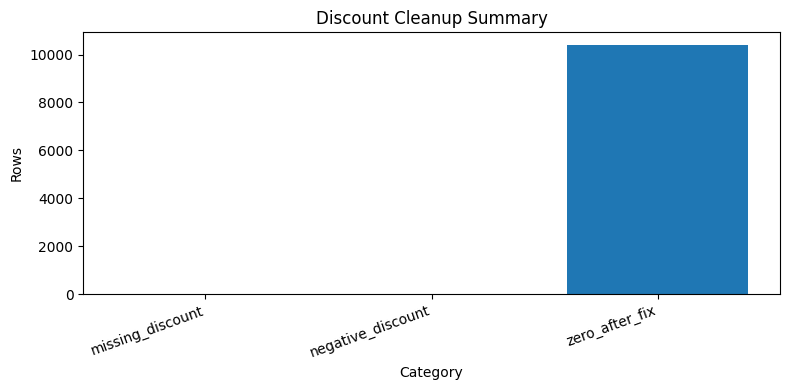

In [16]:
df_discount = con.execute("""
SELECT 'missing_discount' AS category, SUM(CASE WHEN discount_raw IS NULL THEN 1 ELSE 0 END) AS row_count
FROM silver.step03_discount_fixed
UNION ALL
SELECT 'negative_discount', SUM(CASE WHEN TRY_CAST(discount_raw AS DOUBLE) < 0 THEN 1 ELSE 0 END)
FROM silver.step03_discount_fixed
UNION ALL
SELECT 'zero_after_fix', SUM(CASE WHEN discount = 0.00 THEN 1 ELSE 0 END)
FROM silver.step03_discount_fixed;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_discount["category"], df_discount["row_count"])
plt.title("Discount Cleanup Summary")
plt.xlabel("Category")
plt.ylabel("Rows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Plot interpretation

This plot shows how often discount values required correction.

If the `negative_discount` bar is high, the source system may have a pricing logic problem. If `missing_discount` is high, the issue is more likely data completeness.


## Cell 12 — Step 4: Parse valid sale dates

### Rule
Accepted formats:
- `MM/DD/YYYY`
- `YYYY-MM-DD`

### Business value
Time analysis is impossible without clean dates. Invalid dates must be identified before Gold analytics.

### How
We parse both allowed formats with `TRY_STRPTIME` and combine them with `COALESCE`.


In [17]:
con.execute("""
CREATE OR REPLACE TABLE silver.step04_date_parsed AS
SELECT
    *,

    -- =========================
    -- DATE PARSING (STEP A)
    -- =========================
    TRY_STRPTIME(sale_date_raw, '%m/%d/%Y')::DATE AS sale_date_us,

    TRY_STRPTIME(sale_date_raw, '%Y-%m-%d')::DATE AS sale_date_iso,

    -- =========================
    -- FINAL DATE (STEP B)
    -- =========================
    COALESCE(
        TRY_STRPTIME(sale_date_raw, '%m/%d/%Y')::DATE,
        TRY_STRPTIME(sale_date_raw, '%Y-%m-%d')::DATE
    ) AS sale_date

FROM silver.step03_discount_fixed;
""")

con.execute("""
SELECT
    COUNT(*) AS rows_checked,
    SUM(CASE WHEN sale_date IS NULL THEN 1 ELSE 0 END) AS invalid_or_missing_sale_date_rows
FROM silver.step04_date_parsed;
""").df()

,rows_checked,invalid_or_missing_sale_date_rows
0,18070,190.0


## Cell 13 — Show examples of bad dates

### Why
Bad examples help students understand what the parser rejects.

### Business value
This is a practical data quality audit that can be shared with upstream teams.


In [18]:
con.execute("""
SELECT
    sale_date_raw,
    COUNT(*) AS row_count
FROM silver.step04_date_parsed
WHERE sale_date IS NULL
GROUP BY sale_date_raw
ORDER BY row_count DESC, sale_date_raw
LIMIT 20;
""").df()

,sale_date_raw,row_count
0,2015/99/99,80
1,None,80
2,31-31-9999,30


## Cell 14 — Step 5: Build rejected records

### Rejection logic
A row is rejected if:
- `sale_type` is missing
- `product_name` is missing
- `customer_email` is missing or invalid
- `quantity` is invalid or <= 0
- `unit_price` is missing or <= 0
- `cost_price` is missing or <= 0
- `store_location` is missing or invalid
- `sale_date` is invalid or missing

### Business value
Rejected rows do not represent trustworthy business events and should not reach Gold.


In [19]:
con.execute("""
CREATE OR REPLACE TABLE silver.rejected_records AS
SELECT
    *,
    -- =========================
    -- REJECTION REASON
    -- =========================
    CASE
        WHEN sale_type IS NULL THEN 'REJECT_MISSING_SALE_TYPE'
        WHEN product_name IS NULL THEN 'REJECT_MISSING_PRODUCT'      
        WHEN customer_name IS NULL THEN 'REJECT_MISSING_CUSTOMER_NAME'     
        WHEN customer_email IS NULL THEN 'REJECT_MISSING_EMAIL'
        WHEN POSITION('@' IN customer_email) = 0 THEN 'REJECT_INVALID_EMAIL'      
        WHEN quantity IS NULL OR quantity <= 0 THEN 'REJECT_INVALID_QUANTITY'     
        WHEN unit_price IS NULL OR unit_price <= 0 THEN 'REJECT_INVALID_UNIT_PRICE'    
        WHEN cost_price IS NULL OR cost_price <= 0 THEN 'REJECT_INVALID_COST_PRICE'    
        WHEN store_location IS NULL THEN 'REJECT_MISSING_STORE_LOCATION'
        WHEN store_location NOT IN ('USA','CANADA','ENGLAND','CHINA') THEN 'REJECT_INVALID_STORE_LOCATION'      
        WHEN sale_date IS NULL THEN 'REJECT_INVALID_OR_MISSING_SALE_DATE' 
        ELSE 'REJECT_OTHER'
    END AS reject_reason

FROM silver.step04_date_parsed

-- =========================
-- FILTER: ONLY BAD RECORDS
-- =========================
WHERE
    sale_type IS NULL
    OR product_name IS NULL
    OR customer_name IS NULL
    OR customer_email IS NULL
    OR POSITION('@' IN customer_email) = 0
    OR quantity IS NULL OR quantity <= 0
    OR unit_price IS NULL OR unit_price <= 0
    OR cost_price IS NULL OR cost_price <= 0
    OR store_location IS NULL
    OR store_location NOT IN ('USA','CANADA','ENGLAND','CHINA')
    OR sale_date IS NULL;
""")

con.execute("""
SELECT reject_reason, COUNT(*) AS row_count
FROM silver.rejected_records
GROUP BY reject_reason
ORDER BY row_count DESC;
""").df()

,reject_reason,row_count
0,REJECT_INVALID_OR_MISSING_SALE_DATE,160
1,REJECT_INVALID_UNIT_PRICE,110
2,REJECT_MISSING_PRODUCT,110
3,REJECT_MISSING_EMAIL,110
4,REJECT_MISSING_SALE_TYPE,100
5,REJECT_MISSING_STORE_LOCATION,80
6,REJECT_INVALID_EMAIL,80
7,REJECT_MISSING_CUSTOMER_NAME,80
8,REJECT_INVALID_STORE_LOCATION,80
9,REJECT_INVALID_QUANTITY,80


## Cell 15 — Plot rejected records by reason

### Why
This shows which rule causes the most rejection.

### Business value
The dominant rejection reason often points to the most important upstream system problem.


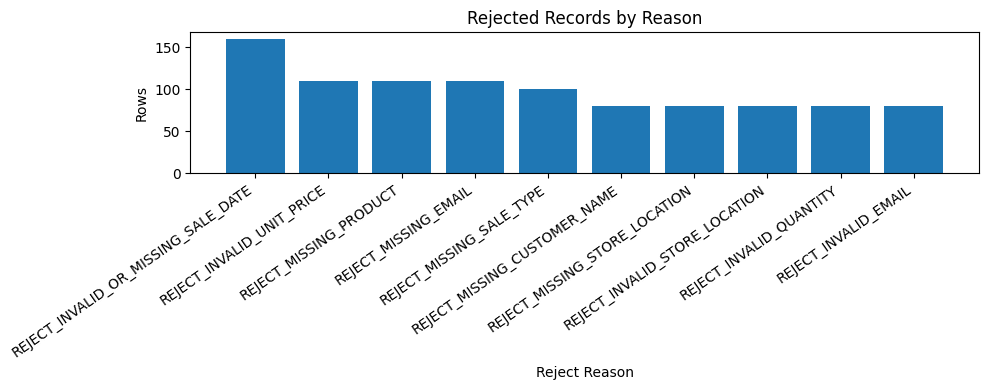

In [20]:
df_rejects = con.execute("""
SELECT reject_reason, COUNT(*) AS row_count
FROM silver.rejected_records
GROUP BY reject_reason
ORDER BY row_count DESC;
""").df()

plt.figure(figsize=(10,4))
plt.bar(df_rejects["reject_reason"], df_rejects["row_count"])
plt.title("Rejected Records by Reason")
plt.xlabel("Reject Reason")
plt.ylabel("Rows")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Plot interpretation

This plot explains *why* rows are lost in Silver. A dominant reason suggests where the source data contract is weakest.


## Cell 16 — Step 6: Build cancelled transactions

### Cancellation logic
If `sale_id` is missing or not an integer, the row is classified as **cancelled**, but only if the rest of the row is otherwise valid.

### Business value
Cancelled transactions still contain business signal:
- customer intent existed
- product demand existed
- revenue opportunity was lost


In [21]:
con.execute("""
CREATE OR REPLACE TABLE silver.cancelled_transactions AS
SELECT
    *
FROM silver.step04_date_parsed
WHERE
    -- =========================
    -- CANCELLED CONDITION
    -- =========================
    (sale_id_raw IS NULL OR TRY_CAST(sale_id_raw AS INTEGER) IS NULL)

    -- =========================
    -- MUST BE OTHERWISE VALID
    -- =========================
    AND sale_type IS NOT NULL
    AND product_name IS NOT NULL    
    AND customer_name IS NOT NULL    
    AND customer_email IS NOT NULL
    AND POSITION('@' IN customer_email) > 0    
    AND quantity IS NOT NULL AND quantity > 0    
    AND unit_price IS NOT NULL AND unit_price > 0   
    AND cost_price IS NOT NULL AND cost_price > 0   
    AND store_location IS NOT NULL
    AND store_location IN ('USA','CANADA','ENGLAND','CHINA')   
    AND sale_date IS NOT NULL;
""")

con.execute("SELECT COUNT(*) AS cancelled_rows FROM silver.cancelled_transactions").df()

,cancelled_rows
0,710


## Cell 17 — Analyze cancelled transactions by product

### Why
This reveals which products are most affected by cancellations.

### Business value
A high cancellation count for a product can suggest inventory, payment, or customer experience issues.


In [22]:
con.execute("""
SELECT
    product_name,
    COUNT(*) AS cancelled_count,
    ROUND(SUM((quantity * unit_price) - discount), 2) AS cancelled_value
FROM silver.cancelled_transactions
GROUP BY product_name
ORDER BY cancelled_count DESC, cancelled_value DESC;
""").df()

,product_name,cancelled_count,cancelled_value
0,IPHONE,106,201359.70
1,HEADPHONES,105,57670.45
2,TV,85,125108.35
3,COMPUTER,79,141187.15
4,BIKE,57,50350.65
5,MACBOOK,54,142861.75
6,SCOOTER,53,41115.50
7,HELMET,52,14448.60
8,IPAD,49,61602.45
9,WATCH,44,34834.95


## Cell 18 — Plot cancelled transactions by product

### Plot meaning
This chart compares cancellation volume across products.

### Business value
It helps business teams focus on which product lines lose the most potential sales.


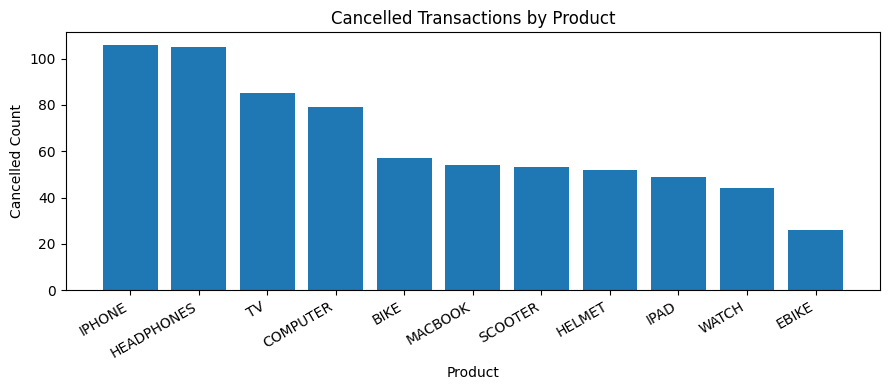

In [23]:
df_cancelled = con.execute("""
SELECT
    product_name,
    COUNT(*) AS cancelled_count
FROM silver.cancelled_transactions
GROUP BY product_name
ORDER BY cancelled_count DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df_cancelled["product_name"], df_cancelled["cancelled_count"])
plt.title("Cancelled Transactions by Product")
plt.xlabel("Product")
plt.ylabel("Cancelled Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Plot interpretation

Tall bars indicate products with more cancelled transactions. This does not automatically mean they are problematic; it may also reflect higher sales volume. The next step is to compare cancellation rate, not just count.


## Cell 19 — Step 7: Build trusted Silver records

### Why
Gold should be built only from rows that are:
- not rejected
- not cancelled
- consistent enough for analytics

### Business value
This creates the warehouse-ready operational truth.


In [24]:
con.execute("""
CREATE OR REPLACE TABLE silver.sales_clean AS
SELECT
    -- =========================
    -- CORE IDENTIFIERS
    -- =========================
    TRY_CAST(sale_id_raw AS INTEGER) AS sale_id,

    sale_type,
    COALESCE(sales_channel, 'UNKNOWN') AS sales_channel,

    -- =========================
    -- PRODUCT
    -- =========================
    product_name,
    product_category,
    product_brand,

    -- =========================
    -- CUSTOMER
    -- =========================
    customer_name,
    customer_email,
    customer_country,
    customer_city,
    customer_gender,
    customer_segment,

    -- =========================
    -- MEASURES
    -- =========================
    quantity,
    unit_price,
    cost_price,
    discount,   -- ✅ use from step03

    -- =========================
    -- STORE
    -- =========================
    store_location,
    store_region,
    store_manager,

    -- =========================
    -- DATE
    -- =========================
    sale_date,  -- ✅ use from step04

    order_timestamp,
    delivery_date,
    order_status,

    -- =========================
    -- DERIVED METRICS
    -- =========================
    (quantity * unit_price) - discount AS final_sale_price,

    (quantity * cost_price) AS total_cost,

    ((quantity * unit_price) - discount) - (quantity * cost_price) AS profit

FROM silver.step04_date_parsed

-- =========================
-- 🔥 KEEP ONLY VALID (NON-REJECTED, NON-CANCELLED)
-- =========================
WHERE
    -- must have valid sale_id (exclude cancelled)
    TRY_CAST(sale_id_raw AS INTEGER) IS NOT NULL

    -- basic validity
    AND sale_type IS NOT NULL
    AND product_name IS NOT NULL
    AND customer_name IS NOT NULL

    AND customer_email IS NOT NULL
    AND POSITION('@' IN customer_email) > 0

    AND quantity IS NOT NULL AND quantity > 0
    AND unit_price IS NOT NULL AND unit_price > 0
    AND cost_price IS NOT NULL AND cost_price > 0

    AND store_location IS NOT NULL
    AND store_location IN ('USA','CANADA','ENGLAND','CHINA')

    AND sale_date IS NOT NULL;
""")

In [43]:
con.execute("""
SELECT count(*) AS num_of_silver_sales_clean 
FROM silver.sales_clean
""").df()

,num_of_silver_sales_clean
0,16370


In [44]:
con.execute("""
SELECT * 
FROM silver.sales_clean 
LIMIT 12""").df()

,sale_id,sale_type,sales_channel,product_name,product_category,product_brand,customer_name,customer_email,customer_country,customer_city,...,store_location,store_region,store_manager,sale_date,order_timestamp,delivery_date,order_status,final_sale_price,total_cost,profit
0,17,ON-LINE,WEB,MACBOOK,COMPUTERS,APPLE,Evelyn Lee,evelyn.lee38@yahoo.com,FRANCE,LYON,...,CHINA,EAST,Li Chen,2017-01-16,2017-01-16 15:17:24,2017-01-24,COMPLETED,2022.00,1498.66,523.34
1,19,IN-STORE,STORE,EBIKE,MOBILITY,TREK,Lily Miller,lily.miller69@gmail.com,USA,NEW YORK,...,CHINA,SOUTH,Wei Zhang,2016-12-07,2016-12-07 17:18:27,2016-12-07,COMPLETED,6369.00,4588.23,1780.77
2,37,IN-STORE,STORE,HELMET,ACCESSORY,SPECIALIZED,Amelia Walker,amelia.walker26@proton.me,GERMANY,BERLIN,...,USA,EAST,Linda Parker,2015-06-17,2015-06-17 08:42:28,2015-06-19,COMPLETED,83.00,63.77,19.23
3,42,ON-LINE,MOBILE_APP,WATCH,WEARABLE,APPLE,Amir Perez,amir.perez69@outlook.com,ENGLAND,MANCHESTER,...,USA,WEST,Jay Smith,2015-10-19,2015-10-19 09:14:05,2015-10-24,COMPLETED,681.00,418.32,262.68
4,85,ON-LINE,WEB,BIKE,MOBILITY,GIANT,Michael Jackson,michael.jackson47@icloud.com,CHINA,SHENZHEN,...,CHINA,EAST,Li Chen,2015-03-23,2015-03-23 18:32:29,2015-03-27,COMPLETED,1788.00,1277.96,510.04
5,96,IN-STORE,STORE,TV,ELECTRONICS,SONY,Sophia Martin,sophia.martin74@gmail.com,USA,NEW YORK,...,USA,EAST,Jay Smith,2015-05-07,2015-05-07 09:07:12,2015-05-14,COMPLETED,2589.70,2092.32,497.38
6,99,IN-STORE,STORE,HELMET,ACCESSORY,GIRO,Sara Hall,sara.hall91@outlook.com,USA,CHICAGO,...,CHINA,EAST,Li Chen,2015-08-13,2015-08-13 18:00:37,2015-08-14,COMPLETED,107.00,68.13,38.87
7,103,ON-LINE,WEB,HELMET,ACCESSORY,BELL,Samuel Smith,samuel.smith53@icloud.com,ITALY,ROME,...,CANADA,CENTRAL,Emily Chen,2016-11-17,2016-11-17 21:43:27,2016-11-19,COMPLETED,122.00,79.81,42.19
8,122,ON-LINE,WEB,HELMET,ACCESSORY,BELL,Lucas Evans,lucas.evans5@yahoo.com,GERMANY,HAMBURG,...,CHINA,EAST,Li Chen,2015-08-27,2015-08-27 09:45:27,2015-09-04,COMPLETED,173.85,128.78,45.07
9,134,ON-LINE,MOBILE_APP,MACBOOK,COMPUTERS,APPLE,Aria Garcia,aria.garcia7@proton.me,INDIA,MUMBAI,...,USA,WEST,Jay Smith,2017-06-15,2017-06-15 17:41:34,2017-06-20,COMPLETED,2990.00,2372.00,618.00


## Cell 20 — Build the pipeline funnel

### Why
A funnel summarizes how the dataset shrinks from messy input to trusted output.

### Business value
This is a high-value governance and teaching artifact.


In [45]:
con.execute("""
SELECT 'bronze.sales_raw' AS stage, COUNT(*) AS row_count FROM bronze.sales_raw
UNION ALL
SELECT 'silver.step01_dedup', COUNT(*) FROM silver.step01_dedup
UNION ALL
SELECT 'silver.rejected_records', COUNT(*) FROM silver.rejected_records
UNION ALL
SELECT 'silver.cancelled_transactions', COUNT(*) FROM silver.cancelled_transactions
UNION ALL
SELECT 'silver.sales_clean', COUNT(*) FROM silver.sales_clean;
""").df()

,stage,row_count
0,bronze.sales_raw,18490
1,silver.step01_dedup,18070
2,silver.rejected_records,990
3,silver.cancelled_transactions,710
4,silver.sales_clean,16370


## Cell 21 — Plot the funnel

### Plot meaning
This chart shows how many rows survive each major stage.

### Business value
It turns a complex cleaning pipeline into an easily explainable picture for stakeholders.


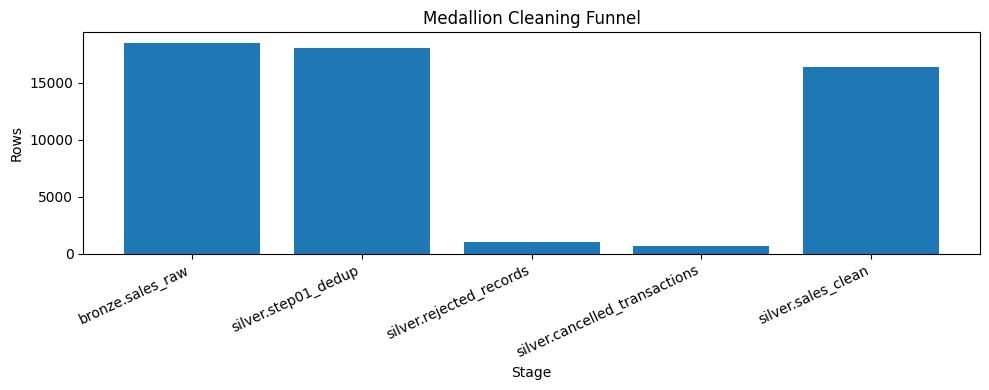

In [46]:
df_funnel = con.execute("""
SELECT 'bronze.sales_raw' AS stage, COUNT(*) AS row_count FROM bronze.sales_raw
UNION ALL
SELECT 'silver.step01_dedup', COUNT(*) FROM silver.step01_dedup
UNION ALL
SELECT 'silver.rejected_records', COUNT(*) FROM silver.rejected_records
UNION ALL
SELECT 'silver.cancelled_transactions', COUNT(*) FROM silver.cancelled_transactions
UNION ALL
SELECT 'silver.sales_clean', COUNT(*) FROM silver.sales_clean;
""").df()

plt.figure(figsize=(10,4))
plt.bar(df_funnel["stage"], df_funnel["row_count"])
plt.title("Medallion Cleaning Funnel")
plt.xlabel("Stage")
plt.ylabel("Rows")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Plot interpretation

The funnel shows the cumulative effect of rule enforcement. If too many rows are lost, the upstream system may be unstable. If very few rows are lost, the source data is relatively healthy.


# Gold Layer

Gold converts trusted Silver data into analytics-ready structures.


## Cell 22 — Create Gold dimensions

### Why
Dimension tables store reusable business entities and descriptive attributes.

### Business value
They support slicing, grouping, and drill-down analytics.


In [51]:
con.execute("""

CREATE OR REPLACE TABLE gold.dim_customer AS
SELECT
    ROW_NUMBER() OVER (ORDER BY customer_email) AS customer_key,
    customer_email,
    -- =========================
    -- CUSTOMER ATTRIBUTES
    -- =========================
    MIN(customer_name) AS customer_name,
    MIN(customer_country) AS customer_country,
    MIN(customer_city) AS customer_city,
    MIN(customer_gender) AS customer_gender,
    MIN(customer_segment) AS customer_segment
FROM silver.sales_clean
GROUP BY customer_email;
""")

In [52]:
df_funnel = con.execute("""
SELECT * 
FROM gold.dim_customer
LIMIT 5;
""").df()

df_funnel

,customer_key,customer_email,customer_name,customer_country,customer_city,customer_gender,customer_segment
0,1,abigail.campbell87@yahoo.com,Abigail Campbell,CHINA,SHENZHEN,OTHER,PREMIUM
1,2,abigail.khan36@icloud.com,Abigail Khan,INDIA,BENGALURU,OTHER,REGULAR
2,3,abigail.moreau33@gmail.com,Abigail Moreau,USA,CHICAGO,FEMALE,STUDENT
3,4,abigail.parker95@icloud.com,Abigail Parker,MEXICO,GUADALAJARA,FEMALE,STUDENT
4,5,abigail.perez19@proton.me,Abigail Perez,USA,SAN JOSE,MALE,REGULAR


In [54]:
con.execute("""

CREATE OR REPLACE TABLE gold.dim_product AS
SELECT
    ROW_NUMBER() OVER (ORDER BY product_name, product_category, product_brand) AS product_key,
    product_name,
    product_category,
    product_brand
FROM (
    SELECT DISTINCT
        product_name,
        product_category,
        product_brand
    FROM silver.sales_clean
);
""")

In [55]:
con.execute("""
SELECT * 
FROM gold.dim_product;
""").df()

,product_key,product_name,product_category,product_brand
0,1,BIKE,MOBILITY,CANNONDALE
1,2,BIKE,MOBILITY,GIANT
2,3,BIKE,MOBILITY,TREK
3,4,COMPUTER,COMPUTERS,DELL
4,5,COMPUTER,COMPUTERS,HP
5,6,COMPUTER,COMPUTERS,LENOVO
6,7,EBIKE,MOBILITY,GIANT
7,8,EBIKE,MOBILITY,SPECIALIZED
8,9,EBIKE,MOBILITY,TREK
9,10,HEADPHONES,AUDIO,APPLE


In [56]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_store AS
SELECT
    ROW_NUMBER() OVER (ORDER BY store_location, store_region, store_manager) AS store_key,
    store_location,
    store_region,
    store_manager
FROM (
    SELECT DISTINCT
        store_location,
        store_region,
        store_manager
    FROM silver.sales_clean
);
""")

In [57]:
con.execute("""
SELECT * 
FROM gold.dim_store;
""").df()

,store_key,store_location,store_region,store_manager
0,1,CANADA,CENTRAL,Emily Chen
1,2,CANADA,CENTRAL,Noah Bennett
2,3,CANADA,WEST,Emily Chen
3,4,CANADA,WEST,Noah Bennett
4,5,CHINA,EAST,Li Chen
5,6,CHINA,EAST,Wei Zhang
6,7,CHINA,SOUTH,Li Chen
7,8,CHINA,SOUTH,Wei Zhang
8,9,ENGLAND,NORTH,Grace Turner
9,10,ENGLAND,NORTH,Oliver Reed


In [58]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY sale_date) AS date_key,

    -- =========================
    -- CORE
    -- =========================
    sale_date AS full_date,

    -- =========================
    -- YEAR / QUARTER / MONTH
    -- =========================
    EXTRACT(YEAR FROM sale_date) AS year_num,
    EXTRACT(QUARTER FROM sale_date) AS quarter_num,
    EXTRACT(MONTH FROM sale_date) AS month_num,

    STRFTIME(sale_date, '%B') AS month_name,
    STRFTIME(sale_date, '%Y-%m') AS year_month,

    -- =========================
    -- DAY FEATURES (VERY USEFUL)
    -- =========================
    EXTRACT(DAY FROM sale_date) AS day_of_month,

    EXTRACT(DOW FROM sale_date) AS day_of_week_num,
    STRFTIME(sale_date, '%A') AS day_of_week_name,

    CASE 
        WHEN EXTRACT(DOW FROM sale_date) IN (0, 6) THEN 'WEEKEND'
        ELSE 'WEEKDAY'
    END AS day_type,

    -- =========================
    -- WEEK FEATURES
    -- =========================
    EXTRACT(WEEK FROM sale_date) AS week_of_year,

    -- =========================
    -- SORT KEYS (VERY IMPORTANT)
    -- =========================
    CAST(STRFTIME(sale_date, '%Y%m%d') AS INTEGER) AS date_int_key

FROM (
    SELECT DISTINCT sale_date
    FROM silver.sales_clean
);
""")

In [60]:
con.execute("""
SELECT COUNT(*) AS num_of_dates 
FROM gold.dim_date;
""").df()

,num_of_dates
0,1096


In [61]:
con.execute("""
SELECT * 
FROM gold.dim_date
LIMIT 10;
""").df()

,date_key,full_date,year_num,quarter_num,month_num,month_name,year_month,day_of_month,day_of_week_num,day_of_week_name,day_type,week_of_year,date_int_key
0,1,2015-01-01,2015,1,1,January,2015-01,1,4,Thursday,WEEKDAY,1,20150101
1,2,2015-01-02,2015,1,1,January,2015-01,2,5,Friday,WEEKDAY,1,20150102
2,3,2015-01-03,2015,1,1,January,2015-01,3,6,Saturday,WEEKEND,1,20150103
3,4,2015-01-04,2015,1,1,January,2015-01,4,0,Sunday,WEEKEND,1,20150104
4,5,2015-01-05,2015,1,1,January,2015-01,5,1,Monday,WEEKDAY,2,20150105
5,6,2015-01-06,2015,1,1,January,2015-01,6,2,Tuesday,WEEKDAY,2,20150106
6,7,2015-01-07,2015,1,1,January,2015-01,7,3,Wednesday,WEEKDAY,2,20150107
7,8,2015-01-08,2015,1,1,January,2015-01,8,4,Thursday,WEEKDAY,2,20150108
8,9,2015-01-09,2015,1,1,January,2015-01,9,5,Friday,WEEKDAY,2,20150109
9,10,2015-01-10,2015,1,1,January,2015-01,10,6,Saturday,WEEKEND,2,20150110


In [63]:
# List of Tables in GOLD Schema:

con.execute("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'gold'
ORDER BY table_name;
""").df()

,table_name
0,dim_customer
1,dim_date
2,dim_product
3,dim_store
4,fact_sales


## Cell 23 — Create the Gold fact table

### Why
The fact table stores measurable business events and connects to dimensions.

### Business value
This is the center of OLAP analysis.


In [ ]:
con.execute("""
CREATE OR REPLACE TABLE gold.fact_sales AS
SELECT
    s.sale_id,

    -- =========================
    -- DIMENSION KEYS
    -- =========================
    dc.customer_key,
    dp.product_key,
    ds.store_key,
    dd.date_key,

    -- =========================
    -- DEGENERATE DIMENSIONS
    -- =========================
    s.sale_type,
    s.sales_channel,

    -- =========================
    -- MEASURES
    -- =========================
    s.quantity,
    s.unit_price,
    s.cost_price,
    s.discount,
    s.final_sale_price,
    s.total_cost,
    s.profit

FROM silver.sales_clean s

-- =========================
-- CORRECT JOINS
-- =========================
JOIN gold.dim_customer dc 
    ON s.customer_email = dc.customer_email

JOIN gold.dim_product dp 
    ON s.product_name = dp.product_name
   AND s.product_category = dp.product_category
   AND s.product_brand = dp.product_brand

JOIN gold.dim_store ds 
    ON s.store_location = ds.store_location
   AND s.store_region = ds.store_region
   AND s.store_manager = ds.store_manager

JOIN gold.dim_date dd 
    ON s.sale_date = dd.full_date;
""")

con.execute("SELECT COUNT(*) AS num_of_fact_rows FROM gold.fact_sales").df()

In [65]:
con.execute("SELECT * FROM gold.fact_sales LIMIT 5").df()

,sale_id,customer_key,product_key,store_key,date_key,sale_type,sales_channel,quantity,unit_price,cost_price,discount,final_sale_price,total_cost,profit
0,17,150,18,5,747,ON-LINE,WEB,1,2022.0,1498.66,0.0,2022.0,1498.66,523.34
1,19,309,9,8,707,IN-STORE,STORE,3,2123.0,1529.41,0.0,6369.0,4588.23,1780.77
2,37,24,15,14,168,IN-STORE,STORE,1,83.0,63.77,0.0,83.0,63.77,19.23
3,42,28,25,15,292,ON-LINE,MOBILE_APP,3,227.0,139.44,0.0,681.0,418.32,262.68
4,85,380,2,5,82,ON-LINE,WEB,2,894.0,638.98,0.0,1788.0,1277.96,510.04


## Cell 24 — Show tables by schema

### Why
This gives a compact structural view of the full medallion pipeline.


In [66]:
df_tables = con.execute("""
SELECT
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema IN ('raw','bronze','silver','gold')
ORDER BY table_schema, table_name;
""").df()

for schema, group in df_tables.groupby("table_schema"):
    print(f"\n📦 Schema: {schema.upper()}")
    print("-" * 40)
    print(group["table_name"].to_string(index=False))


📦 Schema: BRONZE
----------------------------------------
sales_raw

📦 Schema: GOLD
----------------------------------------
dim_customer
    dim_date
 dim_product
   dim_store
  fact_sales

📦 Schema: RAW
----------------------------------------
sales_file

📦 Schema: SILVER
----------------------------------------
cancelled_transactions
      rejected_records
           sales_clean
          step01_dedup
   step02_standardized
 step03_discount_fixed
    step04_date_parsed


# Analytics on Gold

These queries demonstrate why Gold exists: reliable business insight.


## Cell 25 — OLAP 1: Final sales by product

### Why
This shows which products generate the most trusted revenue.

### Plot interpretation
A taller bar means that product contributes more final sales. This helps identify top-performing product lines.


In [33]:
con.execute("""
SELECT
    p.product_name,
    ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product_name
ORDER BY total_final_sales DESC;
""").df()

,product_name,total_final_sales
0,IPHONE,4068272.35
1,MACBOOK,3259071.50
2,TV,3093576.50
3,COMPUTER,2766758.80
4,EBIKE,2509020.45
5,IPAD,1806264.35
6,BIKE,1229033.40
7,WATCH,1161346.60
8,HEADPHONES,1089883.10
9,SCOOTER,964628.20


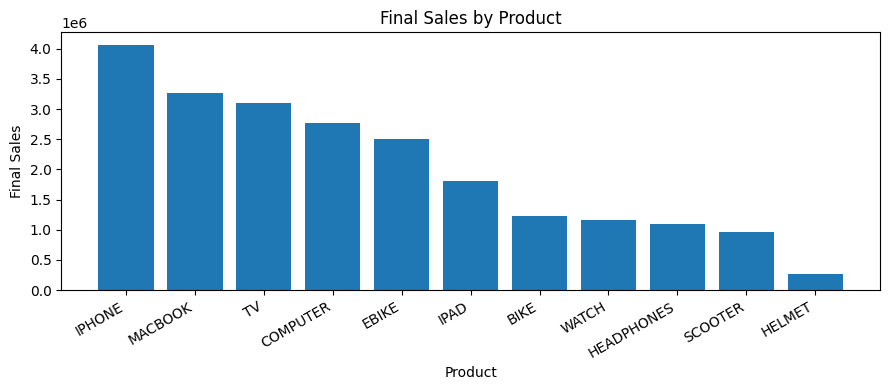

In [67]:
df = con.execute("""
SELECT
    p.product_name,
    SUM(f.final_sale_price) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product_name
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["product_name"], df["total_final_sales"])
plt.title("Final Sales by Product")
plt.xlabel("Product")
plt.ylabel("Final Sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 26 — OLAP 2: Monthly sales trend

### Why
This reveals seasonality and trend patterns in trusted sales.

### Plot interpretation
The line helps detect high and low periods. Peaks may correspond to demand spikes or seasonal effects.


In [68]:
con.execute("""
SELECT
    d.year_month,
    ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_month
ORDER BY d.year_month;
""").df()

,year_month,total_final_sales
0,2015-01,302478.60
1,2015-02,318319.40
2,2015-03,466405.45
3,2015-04,477559.05
4,2015-05,597509.00
5,2015-06,613141.80
6,2015-07,576222.65
7,2015-08,563444.45
8,2015-09,714635.85
9,2015-10,772901.40


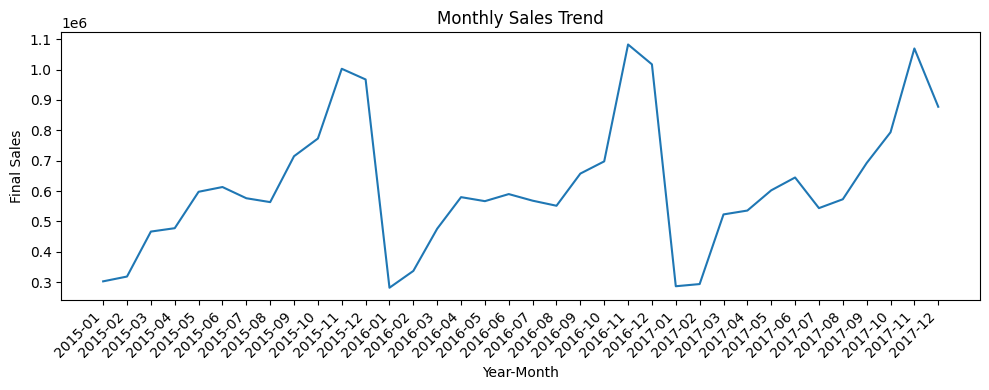

In [69]:
df = con.execute("""
SELECT
    d.year_month,
    SUM(f.final_sale_price) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_month
ORDER BY d.year_month;
""").df()

plt.figure(figsize=(10,4))
plt.plot(df["year_month"], df["total_final_sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Final Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Cell 27 — OLAP 3: Profit by store location

### Why
This compares profitability across store locations.

### Plot interpretation
A larger slice or bar indicates a stronger profit contribution from that store location.


In [70]:
con.execute("""
SELECT
    s.store_location,
    ROUND(SUM(f.profit), 2) AS total_profit
FROM gold.fact_sales f
JOIN gold.dim_store s ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY total_profit DESC;
""").df()

,store_location,total_profit
0,USA,2234795.05
1,CHINA,1587438.80
2,ENGLAND,1060941.29
3,CANADA,1060907.53


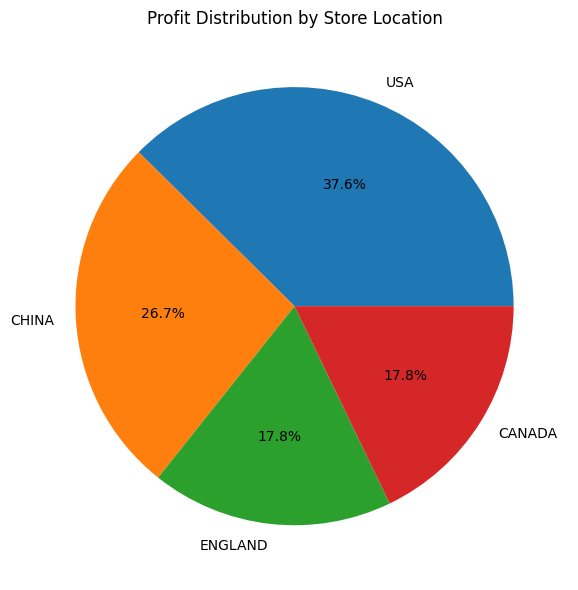

In [71]:
df = con.execute("""
SELECT
    s.store_location,
    SUM(f.profit) AS total_profit
FROM gold.fact_sales f
JOIN gold.dim_store s ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY total_profit DESC;
""").df()

plt.figure(figsize=(6,6))
plt.pie(df["total_profit"], labels=df["store_location"], autopct='%1.1f%%')
plt.title("Profit Distribution by Store Location")
plt.tight_layout()
plt.show()

## Cell 28 — OLAP 4: Sales by customer country

### Why
This shows geographic contribution to revenue.

### Plot interpretation
Taller bars indicate countries generating more sales. This can support localization or expansion decisions.


In [72]:
con.execute("""
SELECT
    c.customer_country,
    ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_final_sales DESC;
""").df()

,customer_country,total_final_sales
0,USA,4530039.85
1,CHINA,4470675.90
2,GERMANY,3992928.10
3,CANADA,2483220.80
4,ENGLAND,2014088.80
5,MEXICO,1485016.50
6,INDIA,1472568.35
7,ITALY,943860.80
8,FRANCE,819914.15


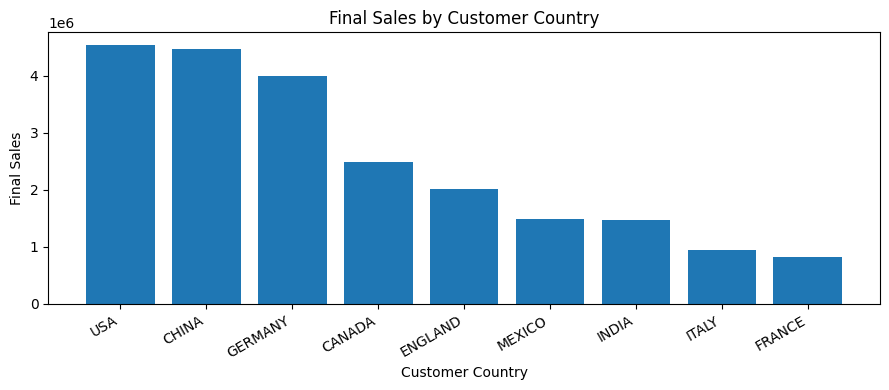

In [73]:
df = con.execute("""
SELECT
    c.customer_country,
    SUM(f.final_sale_price) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["customer_country"], df["total_final_sales"])
plt.title("Final Sales by Customer Country")
plt.xlabel("Customer Country")
plt.ylabel("Final Sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 29 — OLAP 5: Channel comparison

### Why
This compares revenue across sales channels.

### Plot interpretation
The plot reveals which customer interaction channel contributes most to revenue.


In [74]:
con.execute("""
SELECT
    sales_channel,
    COUNT(*) AS transactions,
    ROUND(SUM(final_sale_price), 2) AS total_final_sales,
    ROUND(AVG(final_sale_price), 2) AS avg_transaction_value
FROM gold.fact_sales
GROUP BY sales_channel
ORDER BY total_final_sales DESC;
""").df()

,sales_channel,transactions,total_final_sales,avg_transaction_value
0,WEB,7470,10205410.25,1366.19
1,STORE,5561,7638789.75,1373.64
2,MOBILE_APP,3269,4258849.10,1302.80
3,UNKNOWN,70,109264.15,1560.92


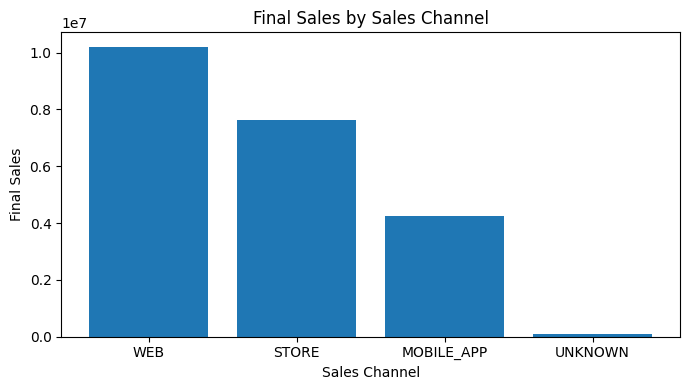

In [75]:
df = con.execute("""
SELECT
    sales_channel,
    SUM(final_sale_price) AS total_final_sales
FROM gold.fact_sales
GROUP BY sales_channel
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(7,4))
plt.bar(df["sales_channel"], df["total_final_sales"])
plt.title("Final Sales by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Final Sales")
plt.tight_layout()
plt.show()

## Final Reflection

This notebook demonstrated how to clean a messy dataset using a medallion pattern:

- Bronze preserved the raw source
- Silver applied business rules step-by-step
- Gold enabled trustworthy analytics

### Most important lesson
Good analytics depend on good data quality design. Cleaning is not just technical work — it protects business decisions.
